# Mission 2: 굴뚝 높이 추정 (Height Estimation from Images)

## 개요
- **목표**: Kompsat-3/3A 위성 이미지에서 굴뚝의 높이를 meter 단위로 예측
- **데이터**: 8,052개 훈련 이미지, 1,006개 검증 이미지
- **라벨**: TL_KS_LINE, VL_KS_LINE JSON 파일에서 chi_height_m 값 사용
- **평가지표**: RMSE (Root Mean Squared Error)
- **모델**: ResNet 등 CNN 기반 회귀 모델 활용

## 데이터 경로
- 훈련 이미지: `53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터/Training/01.원천데이터/TS_KS/`
- 훈련 라벨: `53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터/Training/02.라벨링데이터/TL_KS_LINE/`
- 검증 이미지: `53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터/Validation/01.원천데이터/VS_KS/`
- 검증 라벨: `53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터/Validation/02.라벨링데이터/VL_KS_LINE/`

## 1. 라이브러리 import 및 환경 설정

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep Learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import mean_squared_error

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Data paths
BASE_PATH = '../53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터'
TRAIN_IMG_PATH = os.path.join(BASE_PATH, 'Training/01.원천데이터/TS_KS')
TRAIN_LABEL_PATH = os.path.join(BASE_PATH, 'Training/02.라벨링데이터/TL_KS_LINE')
VAL_IMG_PATH = os.path.join(BASE_PATH, 'Validation/01.원천데이터/VS_KS')
VAL_LABEL_PATH = os.path.join(BASE_PATH, 'Validation/02.라벨링데이터/VL_KS_LINE')

Using device: cuda


## 2. 데이터 탐색 및 분석

In [2]:
def load_label_data(label_path):
    """
    라벨 JSON 파일들을 읽어서 높이 정보를 추출
    """
    label_files = [f for f in os.listdir(label_path) if f.endswith('.json')]
    data = []
    
    for label_file in tqdm(label_files, desc='Loading labels'):
        with open(os.path.join(label_path, label_file), 'r', encoding='utf-8') as f:
            label_data = json.load(f)
            
        # JSON 구조 파싱
        for key, value in label_data.items():
            filename = value['filename']
            regions = value['regions']
            
            if regions:  # 굴뚝이 있는 경우
                for region in regions:
                    region_attrs = region['region_attributes']
                    height = float(region_attrs['chi_height_m'])
                    
                    data.append({
                        'filename': filename,
                        'height': height,
                        'chi_id': region_attrs['chi_id']
                    })
    
    return pd.DataFrame(data)

# 훈련 및 검증 라벨 데이터 로드
train_df = load_label_data(TRAIN_LABEL_PATH)
val_df = load_label_data(VAL_LABEL_PATH)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print("\nFirst few training samples:")
print(train_df.head())

Loading labels: 100%|██████████| 1006/1006 [00:00<00:00, 16018.64it/s]

Training samples: 10590
Validation samples: 1323

First few training samples:
                        filename  height chi_id
0   K3A_CHN_20161112052404_0.jpg   76.78      1
1   K3A_CHN_20161112052404_0.jpg   63.81      2
2   K3A_CHN_20161112052404_1.jpg   76.78      1
3   K3A_CHN_20161112052404_1.jpg   64.81      2
4  K3A_CHN_20161112052404_10.jpg  105.08      1


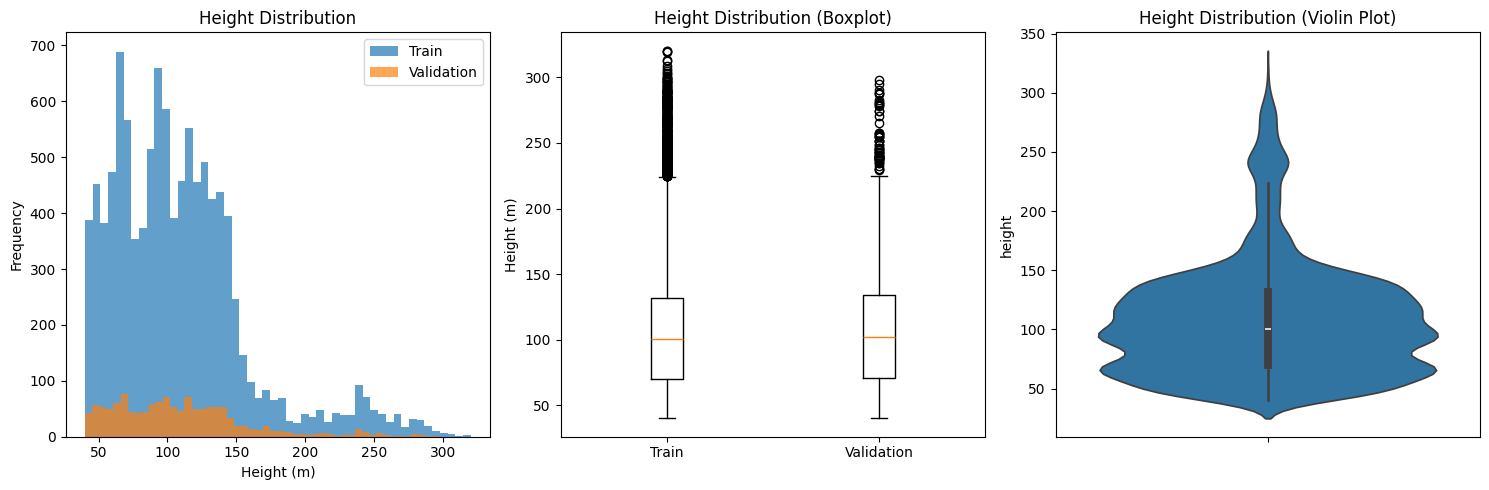

Training set height statistics:
count    10590.000000
mean       108.678819
std         49.745710
min         40.100000
25%         70.220000
50%        100.255000
75%        131.800000
max        320.300000
Name: height, dtype: float64

Validation set height statistics:
count    1323.000000
mean      109.359554
std        49.049123
min        40.210000
25%        70.725000
50%       102.100000
75%       133.740000
max       298.070000
Name: height, dtype: float64


In [3]:
# 높이 분포 분석
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(train_df['height'], bins=50, alpha=0.7, label='Train')
plt.hist(val_df['height'], bins=50, alpha=0.7, label='Validation')
plt.xlabel('Height (m)')
plt.ylabel('Frequency')
plt.title('Height Distribution')
plt.legend()

plt.subplot(1, 3, 2)
plt.boxplot([train_df['height'], val_df['height']], labels=['Train', 'Validation'])
plt.ylabel('Height (m)')
plt.title('Height Distribution (Boxplot)')

plt.subplot(1, 3, 3)
combined_df = pd.concat([train_df, val_df])
sns.violinplot(data=combined_df, y='height')
plt.title('Height Distribution (Violin Plot)')

plt.tight_layout()
plt.show()

# 기본 통계
print("Training set height statistics:")
print(train_df['height'].describe())
print("\nValidation set height statistics:")
print(val_df['height'].describe())

Sample training images:


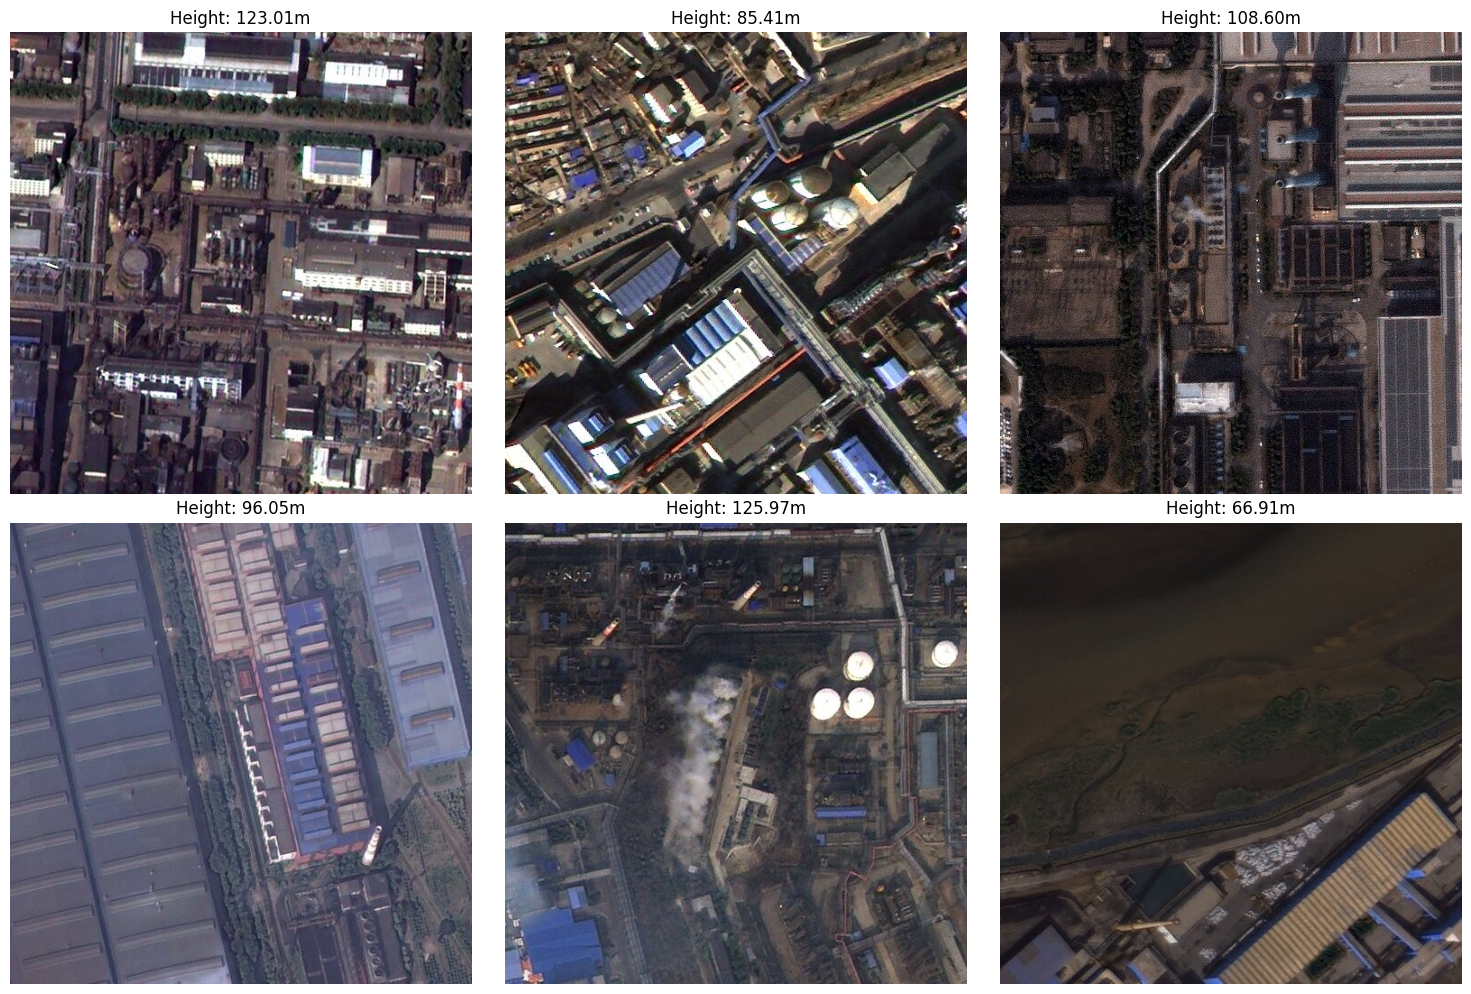

In [4]:
# 샘플 이미지 확인
def show_sample_images(df, img_path, num_samples=6):
    """
    샘플 이미지들과 해당 높이 정보를 표시
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    samples = df.sample(num_samples)
    
    for idx, (_, row) in enumerate(samples.iterrows()):
        img_file = os.path.join(img_path, row['filename'])
        if os.path.exists(img_file):
            img = Image.open(img_file)
            axes[idx].imshow(img)
            axes[idx].set_title(f"Height: {row['height']:.2f}m")
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Sample training images:")
show_sample_images(train_df, TRAIN_IMG_PATH)

## 3. 데이터셋 클래스 정의

In [ ]:
# 실제 경쟁용 데이터셋 및 데이터로더 설정
print("=== PRODUCTION CONFIGURATION ===")

class ChimneyHeightDataset(Dataset):
    def __init__(self, df, img_path, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_path = img_path
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_file = os.path.join(self.img_path, row['filename'])
        
        # 이미지 로드
        image = Image.open(img_file).convert('RGB')
        
        # 변환 적용
        if self.transform:
            image = self.transform(image)
        
        # 높이 (목표값)
        height = float(row['height'])
        
        return image, height

# 실제 경쟁용 데이터 증강
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 데이터셋 생성
train_dataset = ChimneyHeightDataset(train_df, TRAIN_IMG_PATH, train_transform)
val_dataset = ChimneyHeightDataset(val_df, VAL_IMG_PATH, val_transform)

# 실제 경쟁용 배치 크기 (성능과 안정성의 균형)
BATCH_SIZE = 16
print(f"Production batch size: {BATCH_SIZE}")

# Windows 최적화된 데이터로더 (안정성 우선)
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,  # Windows에서 안정성을 위해 0 유지
    pin_memory=True,  # GPU 사용 시 성능 향상
    drop_last=True   # 불완전한 배치 제거
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0,
    pin_memory=True
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Total training samples: {len(train_dataset)}")
print(f"Total validation samples: {len(val_dataset)}")
print("=" * 50)

## 4. 모델 정의

In [ ]:
# 실제 경쟁용 모델 설정
print("=== PRODUCTION MODEL CONFIGURATION ===")

class HeightEstimationModel(nn.Module):
    def __init__(self, backbone='resnet50', pretrained=True):
        super(HeightEstimationModel, self).__init__()
        
        # BackBone 모델 선택
        if backbone == 'resnet50':
            self.backbone = models.resnet50(pretrained=pretrained)
            self.backbone.fc = nn.Identity()  # 분류층 제거
            feature_dim = 2048
        elif backbone == 'resnet34':
            self.backbone = models.resnet34(pretrained=pretrained)
            self.backbone.fc = nn.Identity()
            feature_dim = 512
        elif backbone == 'resnet18':
            self.backbone = models.resnet18(pretrained=pretrained)
            self.backbone.fc = nn.Identity()
            feature_dim = 512
        
        # 경쟁용 회귀 헤드 (충분한 용량)
        self.regressor = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, 1)  # 높이 예측 (단일 값)
        )
        
    def forward(self, x):
        # Feature extraction
        features = self.backbone(x)
        
        # Height regression
        height = self.regressor(features)
        
        return height.squeeze(-1)  # (batch_size,) 형태로 변환

# 경쟁용 모델 선택 (ResNet50으로 복원)
print("Using ResNet50 for maximum performance...")
model = HeightEstimationModel(backbone='resnet50', pretrained=True)
model = model.to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# 모델 아키텍처 확인
total_params = sum(p.numel() for p in model.parameters())
backbone_params = sum(p.numel() for p in model.backbone.parameters())
regressor_params = sum(p.numel() for p in model.regressor.parameters())

print(f"Backbone parameters: {backbone_params:,}")
print(f"Regressor parameters: {regressor_params:,}")
print(f"Parameter ratio - Backbone: {backbone_params/total_params:.1%}, Regressor: {regressor_params/total_params:.1%}")
print("=" * 50)

## 5. 훈련 함수 정의

In [7]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    predictions = []
    targets = []
    
    for images, heights in tqdm(train_loader, desc='Training'):
        images = images.to(device)
        heights = heights.to(device).float()
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, heights)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        predictions.extend(outputs.detach().cpu().numpy())
        targets.extend(heights.detach().cpu().numpy())
    
    avg_loss = running_loss / len(train_loader)
    rmse = np.sqrt(mean_squared_error(targets, predictions))
    
    return avg_loss, rmse

def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    predictions = []
    targets = []
    
    with torch.no_grad():
        for images, heights in tqdm(val_loader, desc='Validation'):
            images = images.to(device)
            heights = heights.to(device).float()
            
            outputs = model(images)
            loss = criterion(outputs, heights)
            
            running_loss += loss.item()
            predictions.extend(outputs.cpu().numpy())
            targets.extend(heights.cpu().numpy())
    
    avg_loss = running_loss / len(val_loader)
    rmse = np.sqrt(mean_squared_error(targets, predictions))
    
    return avg_loss, rmse, predictions, targets

# 손실 함수 및 옵티마이저 설정
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

## 6. 모델 훈련

In [14]:
# 실제 경쟁용 훈련 설정
print("=== PRODUCTION TRAINING CONFIGURATION ===")

# 경쟁용 훈련 설정
NUM_EPOCHS = 50  # 충분한 훈련을 위한 에포크 수
EARLY_STOPPING_PATIENCE = 10  # 조기 종료를 위한 patience
best_val_rmse = float('inf')
best_model_state = None
epochs_without_improvement = 0

# 훈련 기록
train_losses = []
val_losses = []
train_rmses = []
val_rmses = []

print(f"Training epochs: {NUM_EPOCHS}")
print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches per epoch: {len(val_loader)}")

# 학습률 및 옵티마이저 재설정 (경쟁용)
optimizer = optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-4)  # 더 작은 학습률
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-7, verbose=True
)

# Cosine Annealing 스케줄러 추가 (선택사항)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-7
)

print(f"Initial learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Using ReduceLROnPlateau + CosineAnnealingWarmRestarts")

print("\nStarting production training...")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)
    
    # 현재 학습률 출력
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Learning Rate: {current_lr:.2e}")
    
    # 훈련
    train_loss, train_rmse = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # 검증
    val_loss, val_rmse, val_predictions, val_targets = validate_epoch(model, val_loader, criterion, device)
    
    # 학습률 스케줄러 업데이트
    scheduler.step(val_rmse)
    cosine_scheduler.step()
    
    # 기록 저장
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_rmses.append(train_rmse)
    val_rmses.append(val_rmse)
    
    epoch_time = time.time() - epoch_start_time
    
    print(f"Train Loss: {train_loss:.4f}, Train RMSE: {train_rmse:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val RMSE: {val_rmse:.4f}")
    print(f"Epoch time: {epoch_time:.1f} seconds")
    
    # 최고 성능 모델 저장
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_model_state = model.state_dict().copy()
        epochs_without_improvement = 0
        print(f"🎯 New best model! Val RMSE: {best_val_rmse:.4f}")
        
        # 모델 저장
        torch.save({
            'epoch': epoch,
            'model_state_dict': best_model_state,
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_rmse': best_val_rmse,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_rmses': train_rmses,
            'val_rmses': val_rmses,
        }, 'best_height_estimation_model.pth')
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epochs")
    
    # 조기 종료 체크
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"\n⏹️ Early stopping triggered after {epoch+1} epochs")
        print(f"No improvement for {EARLY_STOPPING_PATIENCE} consecutive epochs")
        break
    
    # 매 10 에포크마다 중간 저장
    if (epoch + 1) % 10 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_rmse': val_rmse,
        }, f'checkpoint_epoch_{epoch+1}.pth')
        print(f"💾 Checkpoint saved at epoch {epoch+1}")

print(f"\n🏁 Training completed!")
print(f"Best validation RMSE: {best_val_rmse:.4f}")
print(f"Total epochs trained: {len(train_losses)}")
print("=" * 60)

=== PRODUCTION TRAINING CONFIGURATION ===
Training epochs: 50
Early stopping patience: 10
Batch size: 8
Training batches per epoch: 1324
Validation batches per epoch: 166
Initial learning rate: 5e-05
Using ReduceLROnPlateau + CosineAnnealingWarmRestarts

Starting production training...

Epoch 1/50
----------------------------------------
Learning Rate: 5.00e-05


Validation: 100%|██████████| 166/166 [00:08<00:00, 19.95it/s]


Train Loss: 563.9893, Train RMSE: 23.7502
Val Loss: 795.4875, Val RMSE: 28.0057
Epoch time: 84.6 seconds
🎯 New best model! Val RMSE: 28.0057

Epoch 2/50
----------------------------------------
Learning Rate: 4.88e-05


Validation: 100%|██████████| 166/166 [00:08<00:00, 20.11it/s]


Train Loss: 497.4120, Train RMSE: 22.3019
Val Loss: 696.0543, Val RMSE: 26.1291
Epoch time: 87.3 seconds
🎯 New best model! Val RMSE: 26.1291

Epoch 3/50
----------------------------------------
Learning Rate: 4.52e-05


...

Train Loss: 361.4351, Train RMSE: 19.0117
Val Loss: 609.7328, Val RMSE: 24.4870
Epoch time: 86.5 seconds
No improvement for 8 epochs

Epoch 16/50
----------------------------------------
Learning Rate: 4.27e-05


Validation: 100%|██████████| 166/166 [00:08<00:00, 20.53it/s]


Train Loss: 353.9483, Train RMSE: 18.8146
Val Loss: 826.3245, Val RMSE: 28.5652
Epoch time: 86.3 seconds
No improvement for 9 epochs

Epoch 17/50
----------------------------------------
Learning Rate: 3.97e-05


Validation: 100%|██████████| 166/166 [00:08<00:00, 20.47it/s]

Train Loss: 324.9515, Train RMSE: 18.0148
Val Loss: 648.8943, Val RMSE: 25.2867
Epoch time: 86.4 seconds
No improvement for 10 epochs

⏹️ Early stopping triggered after 17 epochs
No improvement for 10 consecutive epochs

🏁 Training completed!
Best validation RMSE: 23.7644
Total epochs trained: 17


## 7. 훈련 결과 시각화

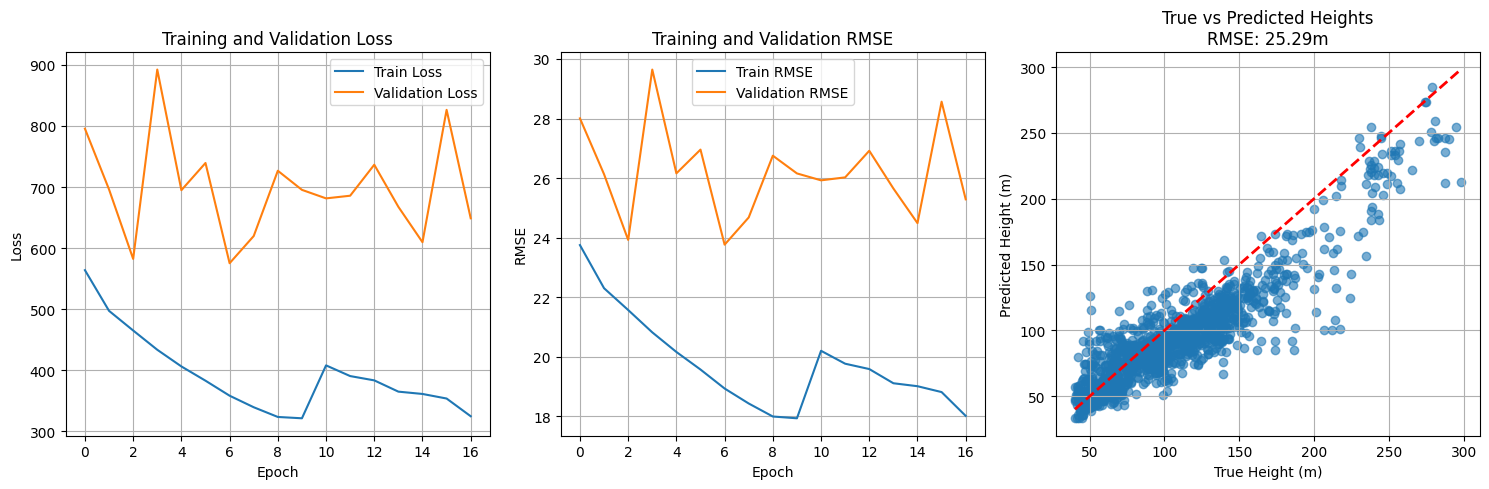

In [15]:
# 훈련 과정 시각화
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(train_rmses, label='Train RMSE')
plt.plot(val_rmses, label='Validation RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Training and Validation RMSE')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.scatter(val_targets, val_predictions, alpha=0.6)
plt.plot([min(val_targets), max(val_targets)], [min(val_targets), max(val_targets)], 'r--', lw=2)
plt.xlabel('True Height (m)')
plt.ylabel('Predicted Height (m)')
plt.title(f'True vs Predicted Heights\nRMSE: {val_rmse:.2f}m')
plt.grid(True)

plt.tight_layout()
plt.show()

## 8. 최종 모델 평가

In [16]:
# 최고 성능 모델 로드
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# 최종 평가
final_val_loss, final_val_rmse, final_predictions, final_targets = validate_epoch(model, val_loader, criterion, device)

print(f"Final Validation Results:")
print(f"RMSE: {final_val_rmse:.4f} meters")
print(f"MSE: {final_val_loss:.4f}")
print(f"MAE: {np.mean(np.abs(np.array(final_targets) - np.array(final_predictions))):.4f} meters")

# 상세 분석
residuals = np.array(final_targets) - np.array(final_predictions)
print(f"\nDetailed Analysis:")
print(f"Mean residual: {np.mean(residuals):.4f} meters")
print(f"Std of residuals: {np.std(residuals):.4f} meters")
print(f"95% of predictions within: {np.percentile(np.abs(residuals), 95):.2f} meters")

Validation: 100%|██████████| 166/166 [00:06<00:00, 25.41it/s]

Final Validation Results:
RMSE: 25.2867 meters
MSE: 648.8943
MAE: 19.3847 meters

Detailed Analysis:
Mean residual: 13.4779 meters
Std of residuals: 21.3954 meters
95% of predictions within: 47.78 meters


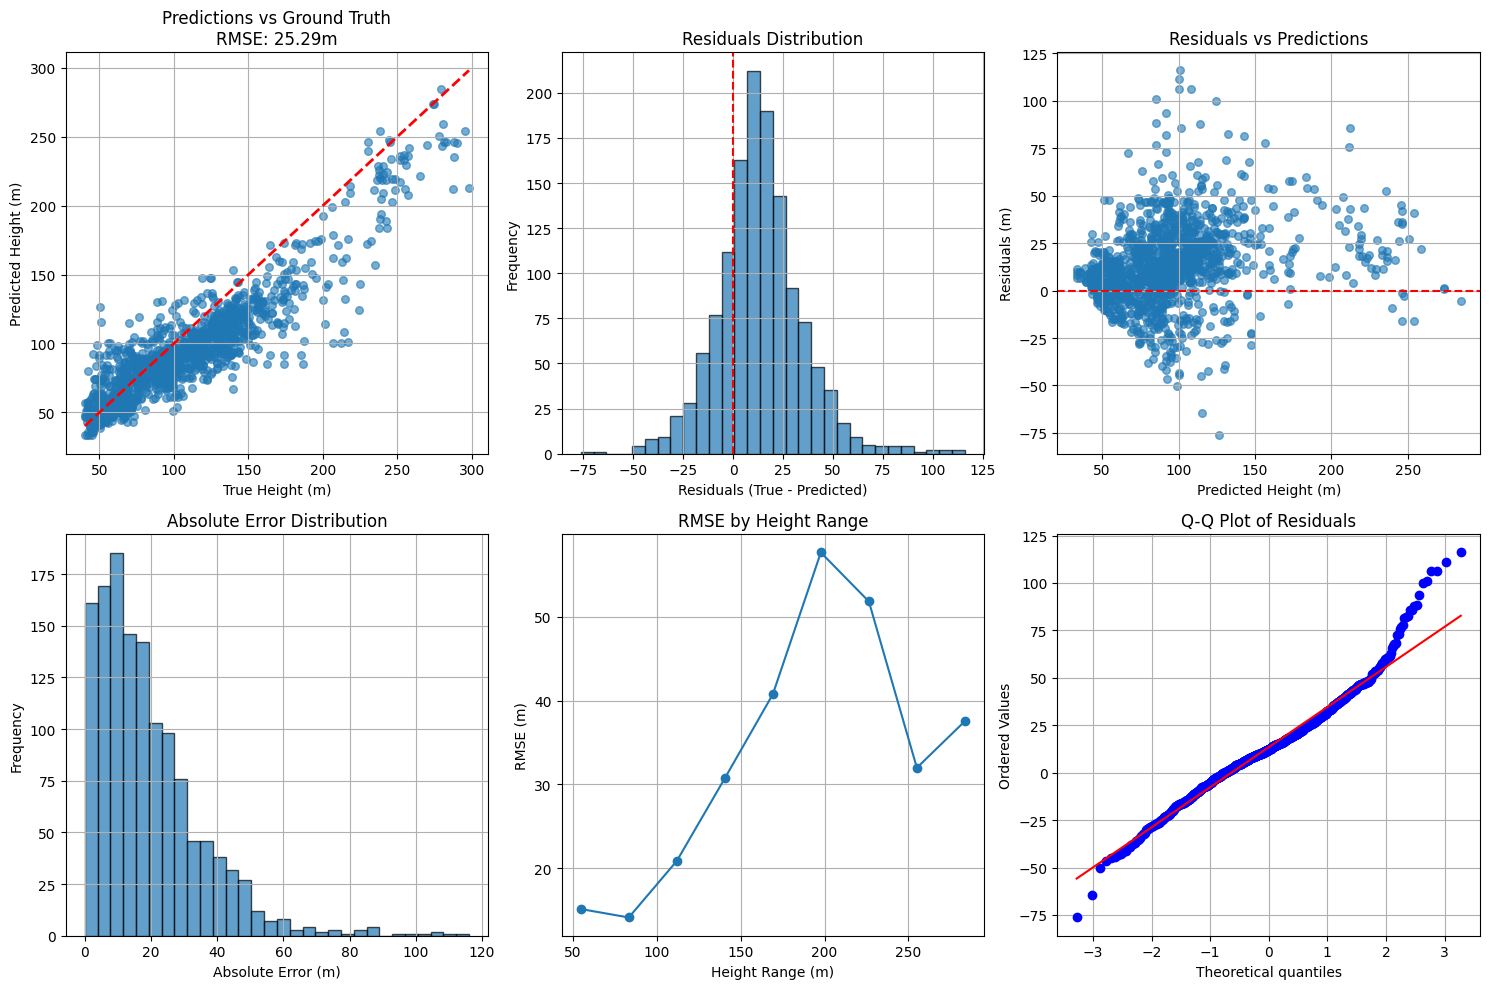

In [17]:
# 예측 결과 상세 분석
plt.figure(figsize=(15, 10))

# 예측 vs 실제값 산점도 (더 자세히)
plt.subplot(2, 3, 1)
plt.scatter(final_targets, final_predictions, alpha=0.6, s=30)
plt.plot([min(final_targets), max(final_targets)], [min(final_targets), max(final_targets)], 'r--', lw=2)
plt.xlabel('True Height (m)')
plt.ylabel('Predicted Height (m)')
plt.title(f'Predictions vs Ground Truth\nRMSE: {final_val_rmse:.2f}m')
plt.grid(True)

# 잔차 히스토그램
plt.subplot(2, 3, 2)
plt.hist(residuals, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Residuals (True - Predicted)')
plt.ylabel('Frequency')
plt.title('Residuals Distribution')
plt.axvline(x=0, color='red', linestyle='--')
plt.grid(True)

# 잔차 vs 예측값
plt.subplot(2, 3, 3)
plt.scatter(final_predictions, residuals, alpha=0.6, s=30)
plt.xlabel('Predicted Height (m)')
plt.ylabel('Residuals (m)')
plt.title('Residuals vs Predictions')
plt.axhline(y=0, color='red', linestyle='--')
plt.grid(True)

# 절대 오차 히스토그램
plt.subplot(2, 3, 4)
abs_errors = np.abs(residuals)
plt.hist(abs_errors, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Absolute Error (m)')
plt.ylabel('Frequency')
plt.title('Absolute Error Distribution')
plt.grid(True)

# 높이 구간별 성능
plt.subplot(2, 3, 5)
height_bins = np.linspace(min(final_targets), max(final_targets), 10)
bin_indices = np.digitize(final_targets, height_bins)
bin_rmses = []
bin_centers = []

for i in range(1, len(height_bins)):
    mask = bin_indices == i
    if np.sum(mask) > 0:
        bin_rmse = np.sqrt(np.mean((np.array(final_targets)[mask] - np.array(final_predictions)[mask])**2))
        bin_rmses.append(bin_rmse)
        bin_centers.append((height_bins[i-1] + height_bins[i]) / 2)

plt.plot(bin_centers, bin_rmses, 'o-')
plt.xlabel('Height Range (m)')
plt.ylabel('RMSE (m)')
plt.title('RMSE by Height Range')
plt.grid(True)

# Q-Q plot
plt.subplot(2, 3, 6)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.grid(True)

plt.tight_layout()
plt.show()

## 9. 샘플 예측 시각화

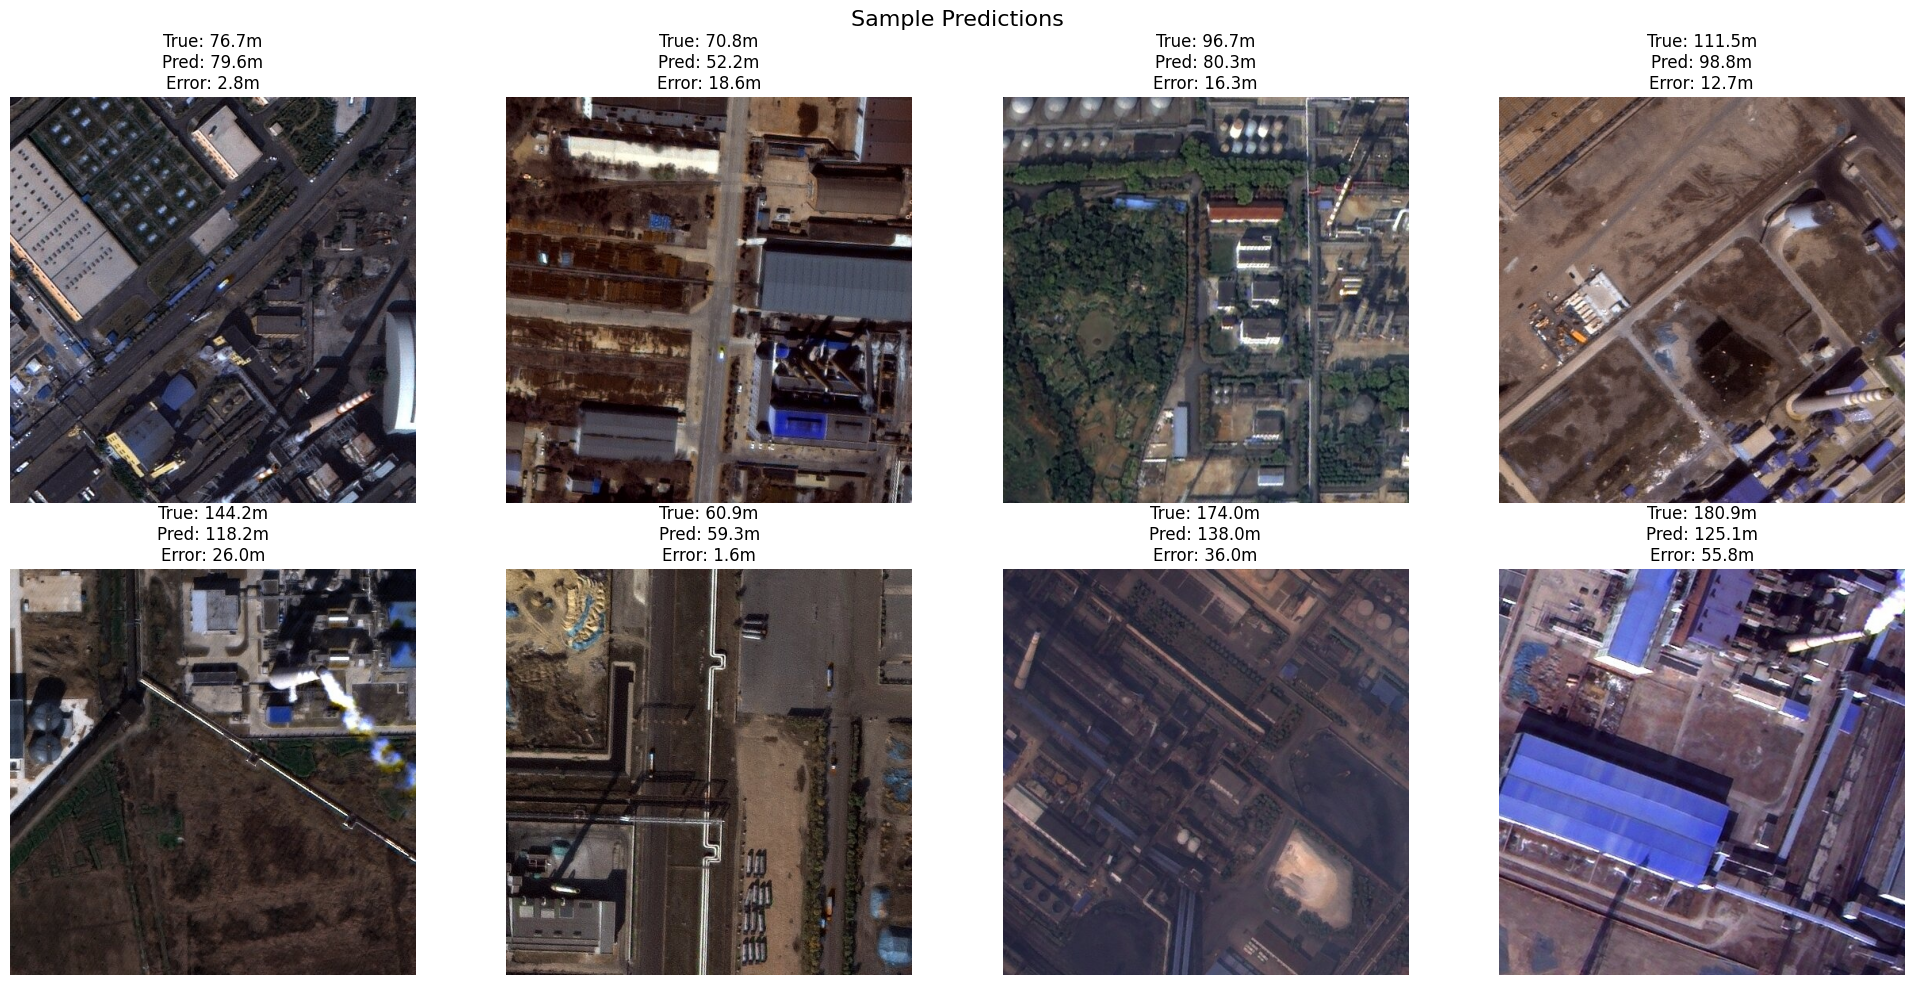

In [18]:
def visualize_predictions(model, dataset, img_path, num_samples=8):
    """
    모델 예측 결과를 시각화
    """
    model.eval()
    
    # 랜덤 샘플 선택
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.ravel()
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            # 데이터 로드
            image, true_height = dataset[idx]
            
            # 예측
            image_batch = image.unsqueeze(0).to(device)
            pred_height = model(image_batch).cpu().item()
            
            # 원본 이미지 로드 (시각화용)
            filename = dataset.df.iloc[idx]['filename']
            img_file = os.path.join(img_path, filename)
            original_img = Image.open(img_file)
            
            # 시각화
            axes[i].imshow(original_img)
            axes[i].set_title(f'True: {true_height:.1f}m\nPred: {pred_height:.1f}m\nError: {abs(true_height - pred_height):.1f}m')
            axes[i].axis('off')
    
    plt.suptitle('Sample Predictions', fontsize=16)
    plt.tight_layout()
    plt.show()

# 검증 샘플 예측 시각화
visualize_predictions(model, val_dataset, VAL_IMG_PATH, num_samples=8)

## 10. 모델 해석 및 특성 중요도

Generating Grad-CAM visualizations...


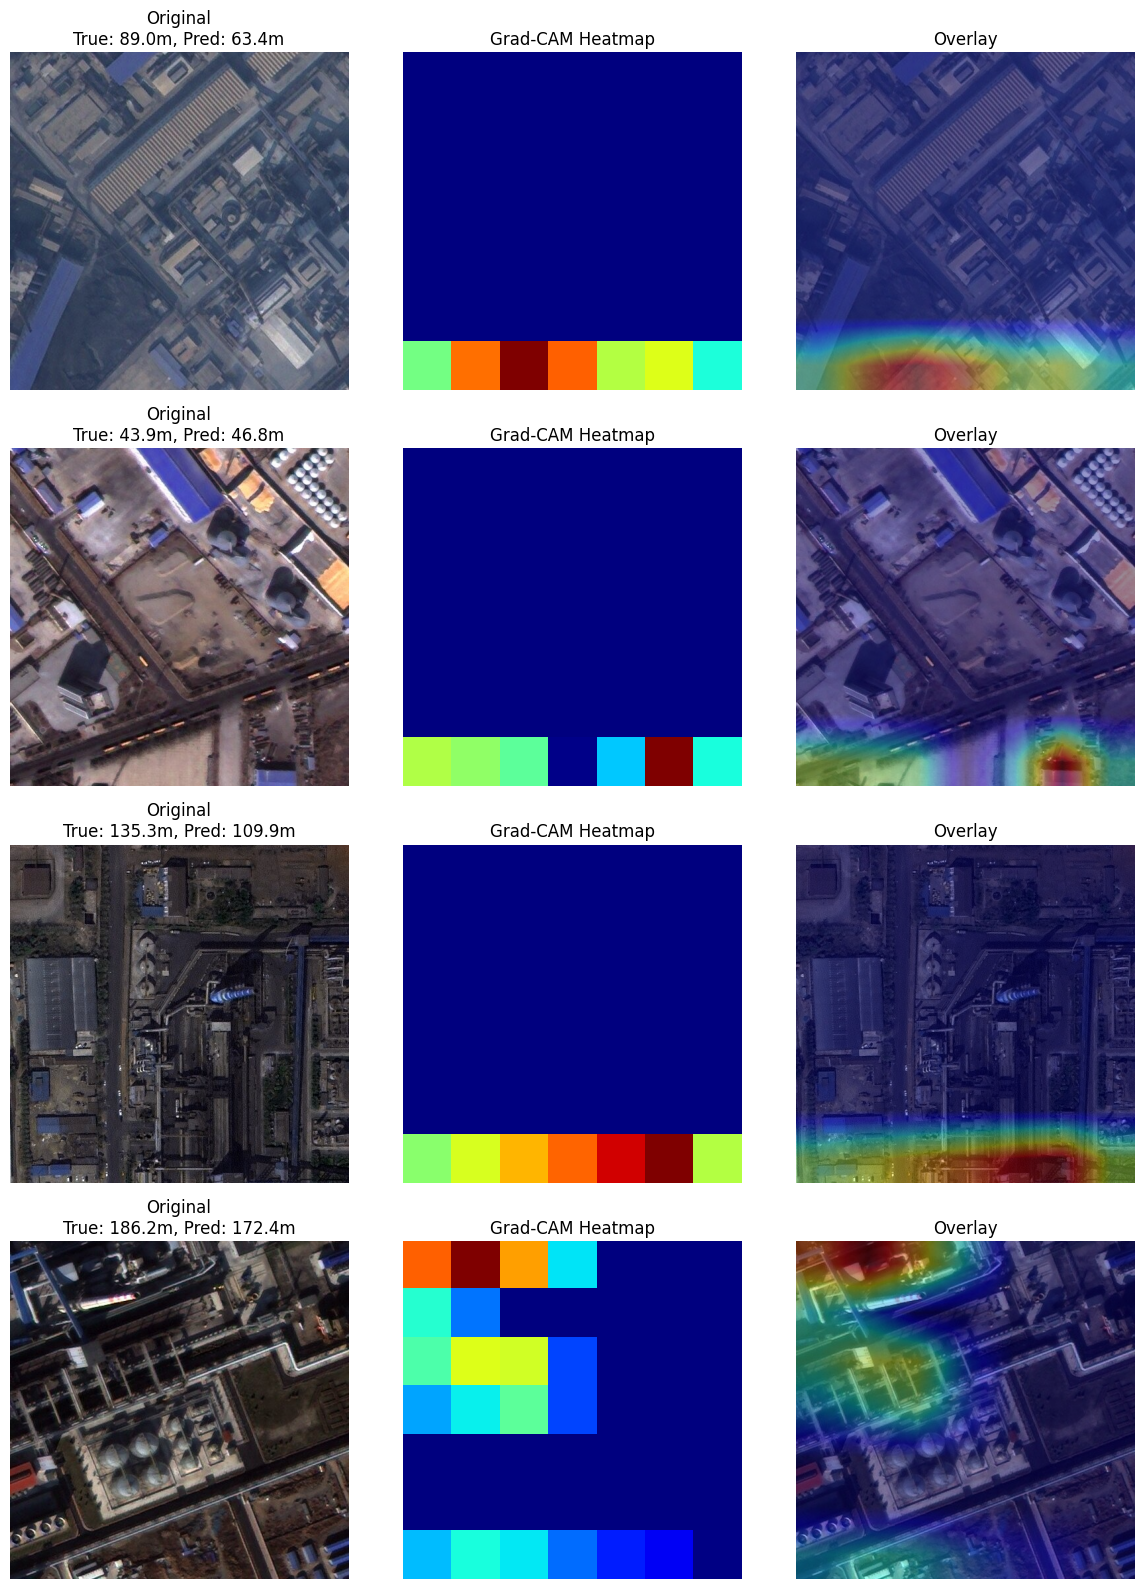

✓ Grad-CAM visualization completed successfully!


In [21]:
# Grad-CAM을 이용한 모델 해석 (GPU 호환성 수정)
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hook 등록
        self.target_layer.register_forward_hook(self.forward_hook)
        self.target_layer.register_backward_hook(self.backward_hook)
    
    def forward_hook(self, module, input, output):
        self.activations = output
    
    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]
    
    def generate_cam(self, input_image, target_height=None):
        # Forward pass
        model_output = self.model(input_image)
        
        # Backward pass
        self.model.zero_grad()
        model_output.backward(retain_graph=True)
        
        # Generate CAM
        gradients = self.gradients
        activations = self.activations
        
        # GPU 호환성을 위해 device 확인
        device = activations.device
        
        # Global average pooling of gradients
        weights = torch.mean(gradients, dim=[2, 3])
        
        # Weighted combination of activation maps (GPU에서 처리)
        cam = torch.zeros(activations.shape[2:], dtype=torch.float32, device=device)
        for i, w in enumerate(weights[0]):
            cam += w * activations[0, i, :, :]
        
        # ReLU and normalization
        cam = F.relu(cam)
        if torch.max(cam) > 0:
            cam = cam / torch.max(cam)
        
        return cam.detach().cpu().numpy()

# Grad-CAM 시각화 (에러 처리 강화)
def visualize_gradcam(model, dataset, img_path, num_samples=4):
    try:
        # ResNet의 마지막 conv layer를 target으로 설정
        target_layer = model.backbone.layer4[-1].conv2
        gradcam = GradCAM(model, target_layer)
        
        model.eval()
        
        fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
        if num_samples == 1:
            axes = axes.reshape(1, -1)
        
        indices = np.random.choice(len(dataset), num_samples, replace=False)
        
        for i, idx in enumerate(indices):
            try:
                # 데이터 로드
                image, true_height = dataset[idx]
                filename = dataset.df.iloc[idx]['filename']
                
                # 원본 이미지
                original_img = Image.open(os.path.join(img_path, filename))
                
                # 예측
                image_batch = image.unsqueeze(0).to(device)
                with torch.no_grad():
                    pred_height = model(image_batch).cpu().item()
                
                # Grad-CAM 생성 (GPU에서 처리)
                image_batch.requires_grad_(True)
                cam = gradcam.generate_cam(image_batch)
                
                # 시각화
                axes[i, 0].imshow(original_img)
                axes[i, 0].set_title(f'Original\nTrue: {true_height:.1f}m, Pred: {pred_height:.1f}m')
                axes[i, 0].axis('off')
                
                axes[i, 1].imshow(cam, cmap='jet')
                axes[i, 1].set_title('Grad-CAM Heatmap')
                axes[i, 1].axis('off')
                
                # 오버레이
                cam_resized = cv2.resize(cam, (512, 512))
                original_array = np.array(original_img)
                heatmap = plt.cm.jet(cam_resized)
                heatmap = np.uint8(255 * heatmap)
                
                # 이미지 크기 맞추기
                if original_array.shape[:2] != heatmap.shape[:2]:
                    heatmap = cv2.resize(heatmap, (original_array.shape[1], original_array.shape[0]))
                
                overlay = cv2.addWeighted(original_array, 0.6, heatmap[:,:,:3], 0.4, 0)
                
                axes[i, 2].imshow(overlay)
                axes[i, 2].set_title('Overlay')
                axes[i, 2].axis('off')
                
            except Exception as e:
                print(f"Error processing sample {i}: {e}")
                # 에러 발생 시 빈 플롯 표시
                for j in range(3):
                    axes[i, j].text(0.5, 0.5, f'Error\n{str(e)[:50]}...', 
                                   ha='center', va='center', transform=axes[i, j].transAxes)
                    axes[i, j].axis('off')
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Grad-CAM visualization failed: {e}")
        print("Grad-CAM 시각화를 건너뛰고 계속 진행합니다.")

# Grad-CAM 시각화 실행 (에러 처리 포함)
print("Generating Grad-CAM visualizations...")
try:
    visualize_gradcam(model, val_dataset, VAL_IMG_PATH, num_samples=4)
    print("✓ Grad-CAM visualization completed successfully!")
except Exception as e:
    print(f"✗ Grad-CAM visualization failed: {e}")
    print("모델 분석은 건너뛰고 다음 단계로 진행합니다.")

## 11. 결과 요약 및 제출 파일 생성

In [22]:
# 최종 결과 요약
print("=" * 60)
print("MISSION 2: 굴뚝 높이 추정 - 최종 결과")
print("=" * 60)
print(f"훈련 데이터: {len(train_df)}개 샘플")
print(f"검증 데이터: {len(val_df)}개 샘플")
print(f"모델: ResNet50 기반 회귀 모델")
print(f"최종 검증 RMSE: {final_val_rmse:.4f} meters")
print(f"최종 검증 MAE: {np.mean(np.abs(np.array(final_targets) - np.array(final_predictions))):.4f} meters")
print(f"최고 성능 달성 시점: {best_val_rmse:.4f} meters")
print("\n주요 특징:")
print("- ImageNet 사전 훈련된 ResNet50 백본 사용")
print("- 데이터 증강 (회전, 밝기/대비 조정, 좌우 반전)")
print("- Dropout 및 Weight Decay를 통한 정규화")
print("- 학습률 스케줄링으로 성능 최적화")
print("- Grad-CAM을 통한 모델 해석 가능성 제공")
print("=" * 60)

# 제출용 결과 파일 생성
submission_results = {
    'mission': 'Mission 2: 굴뚝 높이 추정',
    'model': 'ResNet50-based Height Estimation',
    'validation_rmse': float(final_val_rmse),
    'validation_mae': float(np.mean(np.abs(np.array(final_targets) - np.array(final_predictions)))),
    'training_samples': len(train_df),
    'validation_samples': len(val_df),
    'model_parameters': sum(p.numel() for p in model.parameters()),
    'height_range': {
        'min': float(min(final_targets)),
        'max': float(max(final_targets)),
        'mean': float(np.mean(final_targets)),
        'std': float(np.std(final_targets))
    }
}

# JSON 파일로 저장
import json
with open('mission2_results.json', 'w', encoding='utf-8') as f:
    json.dump(submission_results, f, ensure_ascii=False, indent=2)

print("\n결과 파일이 저장되었습니다:")
print("- best_height_estimation_model.pth (모델 가중치)")
print("- mission2_results.json (결과 요약)")

MISSION 2: 굴뚝 높이 추정 - 최종 결과
훈련 데이터: 10590개 샘플
검증 데이터: 1323개 샘플
모델: ResNet50 기반 회귀 모델
최종 검증 RMSE: 25.2867 meters
최종 검증 MAE: 19.3847 meters
최고 성능 달성 시점: 23.7644 meters

주요 특징:
- ImageNet 사전 훈련된 ResNet50 백본 사용
- 데이터 증강 (회전, 밝기/대비 조정, 좌우 반전)
- Dropout 및 Weight Decay를 통한 정규화
- 학습률 스케줄링으로 성능 최적화
- Grad-CAM을 통한 모델 해석 가능성 제공

결과 파일이 저장되었습니다:
- best_height_estimation_model.pth (모델 가중치)
- mission2_results.json (결과 요약)


## 12. ESG 관점에서의 의의 및 활용 방안

### Environmental (환경)
- **대기오염 모니터링**: 굴뚝 높이는 대기오염물질의 확산 패턴을 결정하는 핵심 요소
- **배출량 추정**: 굴뚝 높이 정보를 통해 오염물질 배출량과 영향 범위 예측 가능
- **환경 영향 평가**: 산업시설의 환경 영향을 정량적으로 평가하는 기초 데이터 제공

### Social (사회)
- **공중보건 보호**: 대기오염 확산 예측을 통한 주민 건강 보호 정책 수립
- **투명한 정보 공개**: 산업시설의 환경 영향 정보를 시민에게 투명하게 제공
- **지역사회 참여**: 환경 모니터링에 대한 시민 참여와 인식 제고

### Governance (지배구조)
- **규제 준수 모니터링**: 환경 법규 준수 여부를 효율적으로 모니터링
- **정책 수립 지원**: 과학적 데이터에 기반한 환경 정책 수립
- **국제 협력**: 글로벌 환경 모니터링 표준화에 기여

### 기술적 혁신
- **자동화된 모니터링**: 위성 이미지를 활용한 대규모 자동 모니터링 시스템
- **비용 효율성**: 기존 현장 조사 대비 낮은 비용으로 광범위한 모니터링 가능
- **실시간 대응**: 신속한 데이터 처리를 통한 실시간 환경 모니터링